In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import copy
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/malakmekyassi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
data = pd.read_csv("data/data.csv", header=None, names=['label', 'text'])
data.shape

(50425, 2)

In [3]:
data.head()

,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   50425 non-null  object
 1   text    50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


In [5]:
data['label'].value_counts()

label
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64

In [6]:
data.isnull().sum()

label    0
text     1
dtype: int64

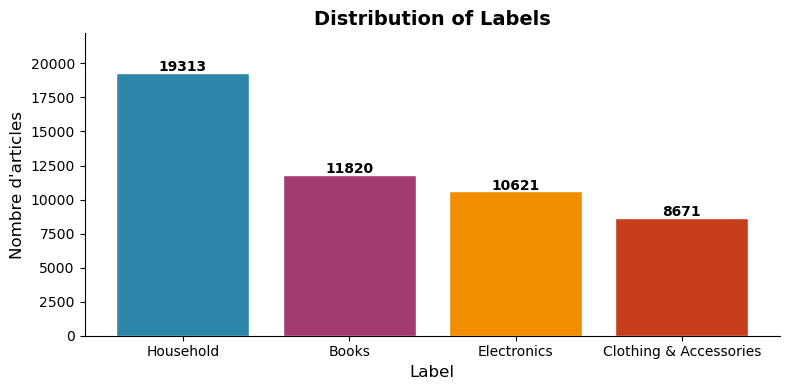

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = data['label'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribution of Labels', fontsize=14, fontweight='bold')
ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel("Nombre d'articles", fontsize=12)
ax.set_ylim(0, counts.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
def simple_stem(word):
    suffixes = ['ing', 'ly', 'ed', 'ious', 'ies', 'ive', 'es', 's', 'ment']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[:-len(suffix)]
    return word
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [simple_stem(word) for word in tokens if word not in STOP_WORDS]
    return ' '.join(tokens)


In [9]:
data.dropna(subset=['text'], inplace=True)
data.reset_index(drop=True, inplace=True)
data['text_clean'] = data['text'].apply(preprocess_text)

avg_before = data['text'].apply(lambda x: len(str(x).split())).mean()
avg_after  = data['text_clean'].apply(lambda x: len(x.split())).mean()
print(f'Longueur moyenne avant prétraitement : {avg_before:.1f} tokens')
print(f'Longueur moyenne après prétraitement : {avg_after:.1f} tokens')
print(f'Réduction : {(1 - avg_after/avg_before)*100:.1f}%')
print(f'\nExemple :')
print(f'  AVANT : {data["text"].iloc[0][:120]}')
print(f'  APRÈS : {data["text_clean"].iloc[0][:120]}')

Longueur moyenne avant prétraitement : 114.2 tokens
Longueur moyenne après prétraitement : 72.5 tokens
Réduction : 36.5%

Exemple :
  AVANT : Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up
  APRÈS : paper plane design fram wall hang motivational office decor art print x inch set paint made synthetic frame uv textur pr


In [10]:
le = LabelEncoder()
data['label_enc'] = le.fit_transform(data['label'])
print('Classes encodées:', dict(zip(le.classes_, le.transform(le.classes_))))

Classes encodées: {'Books': 0, 'Clothing & Accessories': 1, 'Electronics': 2, 'Household': 3}


In [11]:
X = data['text_clean'].values
y = data['label_enc'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
feature_names = np.array(tfidf.get_feature_names_out())

print(f'Train : {X_train_tfidf.shape}')
print(f'Test  : {X_test_tfidf.shape}')
print(f'Vocabulaire : {len(feature_names)} termes')

Train : (40339, 5000)
Test  : (10085, 5000)
Vocabulaire : 5000 termes


In [12]:
def fisher_score(X, y):
    X_dense = X.toarray() if hasattr(X, 'toarray') else X
    overall_mean = np.mean(X_dense, axis=0)
    numerator = np.zeros(X_dense.shape[1])
    denominator = np.zeros(X_dense.shape[1])
    for c in np.unique(y):
        mask = (y == c)
        Xc = X_dense[mask]
        nc = mask.sum()
        numerator += nc * (np.mean(Xc, axis=0) - overall_mean) ** 2
        denominator += nc * np.var(Xc, axis=0)
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return numerator / denominator

In [13]:
K_FEATURES = 1000
METHODS = ['chi2', 'mutual_info', 'info_gain','fisher_score']
METHOD_LABELS = {'chi2': 'Chi-Square',
                 'mutual_info': 'Mutual Information',
                 'info_gain': 'Information Gain',
                 'fisher_score': 'Fisher Score'}
fs_results = {}
for method in METHODS:
    if method == 'chi2':
        selector = SelectKBest(chi2, k=K_FEATURES)
    elif method == 'mutual_info':
        selector = SelectKBest(mutual_info_classif, k=K_FEATURES)
    elif method == 'info_gain':
        selector = SelectKBest(mutual_info_classif, k=K_FEATURES)
    elif method == 'fisher_score':
        scores = fisher_score(X_train_tfidf, y_train)
        top_indices = np.argsort(scores)[-K_FEATURES:]
        selector = SelectKBest(lambda X, y: scores, k=K_FEATURES).fit(X_train_tfidf, y_train)
    else:
        continue
    X_train_fs = selector.fit_transform(X_train_tfidf, y_train)
    X_test_fs = selector.transform(X_test_tfidf)
    fs_results[method] = (X_train_fs, X_test_fs)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserW

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for ax, method in zip(axes, METHODS):
    X_train_fs, _ = fs_results[method]
    selected_features = feature_names[selector.get_support()]
    top_features = selected_features[:20]
    top_scores = selector.scores_[selector.get_support()][:20]
    sns.barplot(x=top_scores, y=top_features, ax=ax, palette='viridis')
    ax.set_title(f'Top 20 features - {METHOD_LABELS[method]}', fontsize=12)
    ax.set_xlabel('Score', fontsize=10)
    ax.set_ylabel('')